# **Building Linear Regression from Scratch**

## **Simple Linear Regression from Scratch**

Here is my attempt at building simple linear regression with Python. Linear regression tries to establish a linear relationship between the input variable x and the output variable y. This relationship is represented as:

$$y = wx + b$$

where $w$ is the coefficient and $b$ is the bias.

For a single data point $x_i$, the predicted value outputted by the model at this point is calculated with the following: $\hat{y_i} = f_{w, b}(x_i) = wx_i + b$.

To evaluate the performance of the linear regresion model, we use the cost function, which calculates the mean squared error. This is represented as:
$$ J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y_i}- y_i)^2 $$

where
* $ m $ = number of training examples
* $ \hat{y_i} - y_i $ = error for a single data point (difference between actual value vs. prediction)
* $\sum_{i=1}^{m} (\hat{y_i} - y_i)^2$ = sum of squared error of all data points

To minimize the cost function, we use gradient descent. The gradient descent algorithm goes as follows:
* Choose starting point (i.e. choose initial values for $w$ and $b$)
* Calculate the gradient of $J(w, b)$ for this point, which is the partial derivatives of $J(w, b)$ with respect to $w$ and $b$ respectively, denoted as 
$$[\frac{\partial J(w, b)}{\partial w}, \frac{\partial J(w, b)}{\partial b}]$$
* Update $w$ and $b$ simultaneously
    * $w = w - \alpha \frac{\partial J(w, b)}{\partial w}$
    * $b = b - \alpha \frac{\partial J(w, b)}{\partial b}$
* Repeat until convergence (or until difference in cost between iterations is small enough)

Note: the terms for the gradient are calculated as follows:
* $\frac{\partial J(w, b)}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y_i}- y_i) x_i$
* $\frac{\partial J(w, b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y_i}- y_i)$

In the file Linear_Regression.py, I wrote functions to calculate the cost, the gradient, and a function for gradient descent, and I compare the resulting coefficients to those outputted from scikit-learn.

In [1]:
# Import all libraries
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'Sample Data')

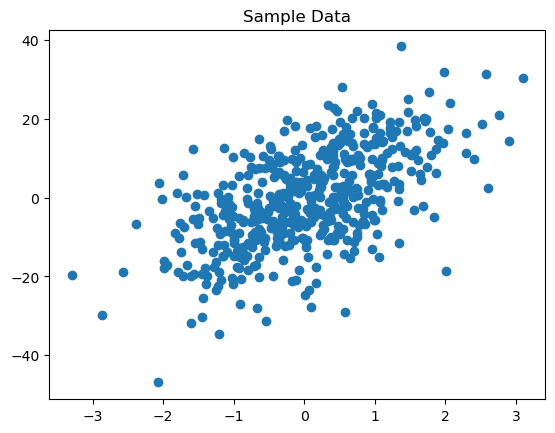

In [2]:
# Create and plot sample data
X, y = make_regression(n_samples = 500, n_features = 1, noise=10, random_state=21)
plt.scatter(X, y)
plt.title("Sample Data")

### **Scikit-learn Linear Regression**

In [3]:
# Create model and find parameters for w and b

model = LinearRegression(fit_intercept=True)
model.fit(X, y)
print("w =", model.coef_[0])
print("b =", model.intercept_)

w = 7.243678156898245
b = -0.6294431445376756


Text(0.5, 1.0, 'Linear Regression from Scikit-learn')

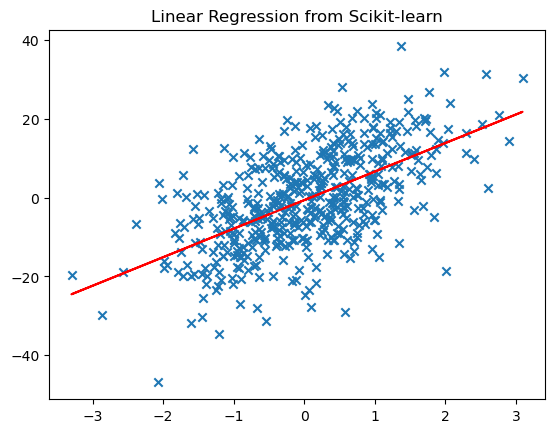

In [4]:
# Use w and b to create the line generated by the model, and compare line to the data points

w = model.coef_[0]
b = model.intercept_
m = X.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * X[i] + b

plt.scatter(X, y, marker="x")
plt.plot(X, predicted, c = 'r')
plt.title("Linear Regression from Scikit-learn")

### **Using Linear_Regression.py**

In [5]:
# Importing Linear_Regression.py. Use the path where the file is stored.

sys.path.append("E:/Project/")
from My_Linear_Reg import MyLinRegression

In [6]:
my_model = MyLinRegression()
my_w, my_b = my_model.gradient_descent(X, y)
print("w =",my_w)
print("b =",my_b)

w = 7.233872739570516
b = -0.6270794303541675


As you can see, the values for $w$ and $b$ obtained from my Python file were very close to those outputted from scikit-learn.

In [7]:
print("scikit-learn R2:",r2_score(y, predicted))
print("My model R2:",r2_score(y, my_model.predict(X)))

scikit-learn R2: 0.34661183244251614
My model R2: 0.3466111674081498


Furthermore, both scikit-learn and my model got identical $R^2$ scores, so both had the same fit for the data. However, scikit-learn scored a bit higher. 

Text(0.5, 1.0, 'My Linear Regression Line')

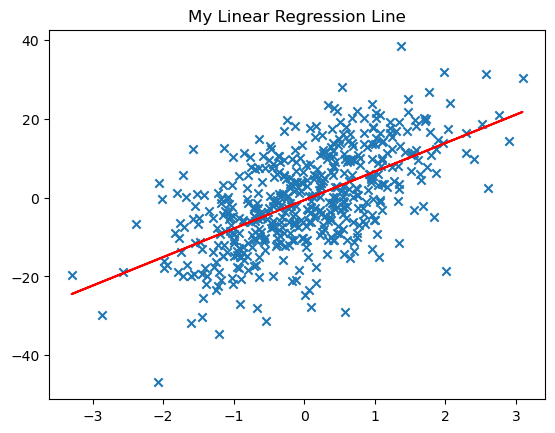

In [8]:
# Plotting my outputted line
my_pred = my_model.predict(X)
plt.plot(X, my_pred, c = 'r')
plt.scatter(X, y, marker='x')
plt.title("My Linear Regression Line")

## **Implementing Multiple Linear Regression**

The idea of linear regression can be extended to include multiple features. In this case, we have n independent variables $x_1, x_2, ..., x_n$, coefficients $w_1, w_2, ..., w_n$ that correspond to each variable, and an intercept $b$.
The relationship between inputs $x_i$ and output y is: $$ y = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$
The model can be rewritten with linear algebra. Let $X = (x_1, x_2, ..., x_n)$ be the independent variables, $W = (w_1, w_2, ..., w_n)$ be the coefficients, then the above formula can be written as $$ y = W \cdot X + b$$
Now, for a single data point $X_j$, the predicted value outputted by the model at this point is calculated with the following: $$\hat{y_i} = f_{W, b}(X_i) = W \cdot X_i + b = w_1 x_{i1} + w_2 x_{i2} + ... + w_n x_{in}$$

In terms of the cost function, there are no changes in the function other than adding in the additional coefficients, i.e., $J(w, b)$ becomes $J(w_1, w_2, ..., w_n, b)$ or $J(W, b)$.

Recall that the gradient of $J(w, b)$ was the partial derivatives of $J(w, b)$ with respect to $w$ and $b$ respectively. So for $J(w_1, w_2, ..., w_n, b)$, the gradient is: $$[\frac{\partial J(w_1, w_2, ..., w_n, b)}{\partial w_1}, \frac{\partial J(w_1, w_2, ..., w_n, b)}{\partial w_2}, ..., \frac{\partial J(w_1, w_2, ..., w_n, b)}{\partial b}]$$

Finally, when it comes to gradient descent, the algorithm stays the same; the only difference is the number of coefficients being updated.

The code can be found in the file Multiple_Regression.py.


In [11]:
from My_Mult_Reg import MyMultRegression

X_mult, y_mult = make_regression(n_samples=1000, n_features=6, noise=10, random_state=42)
MLR = LinearRegression(fit_intercept=True)
MLR.fit(X_mult, y_mult)
print("w =", MLR.coef_)
print("b =", MLR.intercept_)

w = [31.10997704 17.54121714 90.093742   33.86098177 20.35955704 40.11482805]
b = -0.29122295405309107


### **Using Multiple_Regression.py**

In [10]:
MyMultRegModel = MyMultRegression()
MyMultRegModel.set_coeffs(X_mult)
my_coefs, my_intercept = MyMultRegModel.gradient_descent(X_mult, y_mult, 10000,1e-6)
print("my w =", my_coefs)
print("my b =", my_intercept)

my w = [31.108685441722955, 17.53591630902831, 90.08628550306412, 33.857774827975874, 20.35815468521004, 40.11156020527822]
my b = -0.29323600148297846


Thus, our implementation returns identical values to those from scikit-learn. Finally, we can check the $R^2$ scores.

In [12]:
print("scikit-learn R2:",r2_score(y_mult, MLR.predict(X_mult)))
print("My model R2:",r2_score(y_mult, MyMultRegModel.predict(X_mult)))

scikit-learn R2: 0.9916070129041891
My model R2: 0.9916070044683294
